In [1]:
# ==============================
# CELL 1️⃣: Import Libraries
# ==============================

import pandas as pd
import re
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [2]:

uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [3]:
# ==============================
# CELL 3️⃣: Load & Combine Dataset
# ==============================

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  


In [4]:
# ==============================
# CELL 4️⃣: Clean Text
# ==============================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(clean_text)

print("Text cleaning completed!")

Text cleaning completed!


In [5]:
# ==============================
# CELL 5️⃣: Train/Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

print("Data split completed!")

Data split completed!


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF vectorization completed!")

TF-IDF vectorization completed!


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

lr_pred = lr.predict(X_test_vec)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 98.78%


In [12]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_vec, y_train)

svm_pred = svm.predict(X_test_vec)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_acc*100:.2f}%")

SVM Accuracy: 99.54%


In [13]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

nb_pred = nb.predict(X_test_vec)
nb_acc = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy: {nb_acc*100:.2f}%")

Naive Bayes Accuracy: 94.60%


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_vec, y_train)

rf_pred = rf.predict(X_test_vec)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Random Forest Accuracy: 99.76%


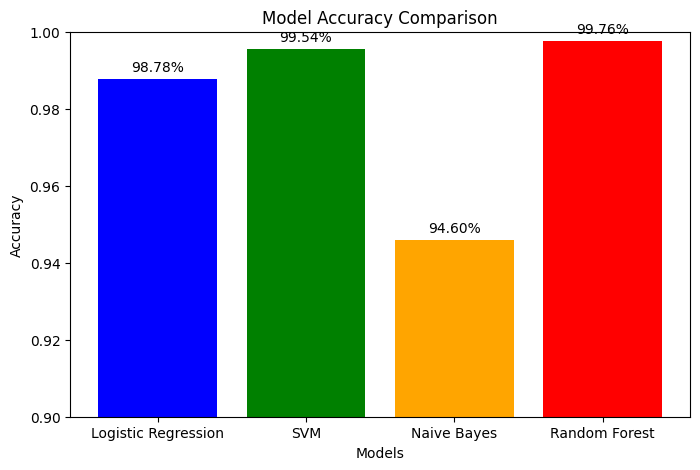

In [15]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "SVM", "Naive Bayes", "Random Forest"]
accuracies = [lr_acc, svm_acc, nb_acc, rf_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['blue','green','orange','red'])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v*100:.2f}%", ha='center')

plt.show()

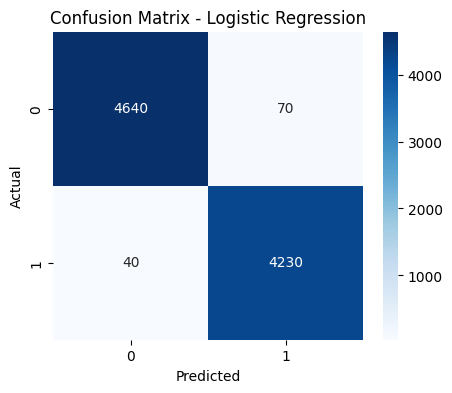

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

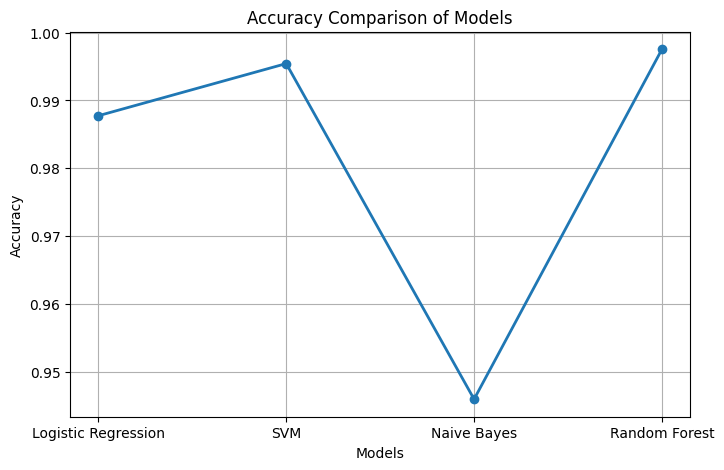

In [17]:
plt.figure(figsize=(8,5))

plt.plot(models, accuracies, marker='o', linewidth=2)

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear SVM", "Naive Bayes", "Random Forest"],
    "Accuracy (%)": [lr_acc*100, svm_acc*100, nb_acc*100, rf_acc*100],
    "Training Time": ["Very Fast", "Fast", "Very Fast", "Slow"],
    "Notes / Strengths": [
        "Works well with sparse TF-IDF, interpretable",
        "Best performance on this dataset",
        "Simple probabilistic model, handles text well",
        "Ensemble model, slower on high-dimensional text"
    ]
})

results

,Model,Accuracy (%),Training Time,Notes / Strengths
0,Logistic Regression,98.775056,Very Fast,"Works well with sparse TF-IDF, interpretable"
1,Linear SVM,99.543430,Fast,Best performance on this dataset
2,Naive Bayes,94.599109,Very Fast,"Simple probabilistic model, handles text well"
3,Random Forest,99.755011,Slow,"Ensemble model, slower on high-dimensional text"
